# Modelo Machine Learning

Este notebook va a consistir en diseñar varios modelos con tareas independientes cada uno. Estas tareas serán:

- Clasificación: Predecir si un estudiante está en riesgo académico. (Target binario)

- Regresión: Predecir la nota exacta de un estudiante. (Target continuo)

- Clustering: Segmentar estudiante en perfiles interpretables. (No se utiliza target)

## 01 - Carga y preprocesamiento

Importamos librerías, cargamos el dataset y realizamos algunos ajustes a los datos.

In [1]:
# Importación de librerías.
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 

# Librerías de ML.
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve,
                             mean_squared_error, mean_absolute_error, r2_score)
from xgboost import XGBClassifier, XGBRegressor

# Configuración de librerías.
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print(f'Librerías cargados correctamente.')

Librerías cargados correctamente.


In [2]:
# Carga del dataset.
ruta = 'data\GAP_clean.csv'
df = pd.read_csv(ruta)

# Restauramos los tipos ordinales.
stress_order = pd.CategoricalDtype(categories=['Low', 'Medium', 'High'], ordered=True)
df['stress_level'] = df['stress_level'].astype(stress_order)

intensity_order = pd.CategoricalDtype(
    categories=['Mínimo (0–1h)', 'Moderado (1–3h)', 'Intenso (3–6h)', 'Extremo (6–8h)'],
    ordered=True
)
df['gaming_intensity'] = df['gaming_intensity'].astype(intensity_order)

print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
df.head()

Dataset cargado: 8,000 filas × 16 columnas


,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades,risk_flag,gaming_intensity
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555,0,NaN
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000,0,NaN
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000,0,NaN
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000,1,NaN
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000,0,NaN


Tras importar las librerías y cargar el dataset, comenzamos el preprocesamiento.

En esta sección, se prepararan las variables para que el modelo pueda aprender de ellas lo mejor posible.

En este caso, comenzaremos por codificar las variables categóricas como son el género, el tipo de juego o el nivel de estrés.

In [3]:
# Codificación de variables categóricas.
le = LabelEncoder() 

df['gender_enc'] = le.fit_transform(df['gender'])
df['gaming_genre_enc'] = le.fit_transform(df['gaming_genre'])
df['stress_level_enc'] = le.fit_transform(df['stress_level'])

print('Variables categóricas codificadas correctamente.')

Variables categóricas codificadas correctamente.


In [4]:
# Selección de características.
features = ['age', 'gaming_hours', 'study_hours', 'sleep_hours',
    'attendance', 'social_activity', 'device_usage',
    'reaction_time_ms', 'addiction_score',
    'gender_enc', 'gaming_genre_enc', 'stress_level_enc']

# Variable objetivo de los modelos.
target_class = 'risk_flag'
target_reg = 'grades'

# Características.
X = df[features]

print('Features seleccionadas:')
print(features)
print(f'\nEstructura de X: {X.shape}')

Features seleccionadas:
['age', 'gaming_hours', 'study_hours', 'sleep_hours', 'attendance', 'social_activity', 'device_usage', 'reaction_time_ms', 'addiction_score', 'gender_enc', 'gaming_genre_enc', 'stress_level_enc']

Estructura de X: (8000, 12)


Se ha utilizado LabelEncoder debido a que en se van a utilizar los modelos XGBoost y RandomForest, que manejan bien las varibles numéricas ordinales.

Para una regresión logística sería más apropiado OneHotEncoder, pero como en este caso hay pocas categorías con poco impacto, se ha utilizado LabelEncoder.

A continuación, se dividirá entre conjuntos de Train/Test.

In [5]:
# Modelo de clasificación.
y_class = df[target_class]
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X, y_class, test_size=0.2, random_state=42, 
                                                                            stratify=y_class) # Stratify para mantener la proporción de clases entre train y test.


# Modelo de regresión.
y_reg = df[target_reg]
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# Mostramos la distribución.
print(f'Clasificación  — Train: {X_train_class.shape[0]:,} | Test: {X_test_class.shape[0]:,}')
print(f'Regresión      — Train: {X_train_reg.shape[0]:,} | Test: {X_test_reg.shape[0]:,}')
print(f'\nBalance en train — riesgo: {y_train_class.mean():.1%}')
print(f'Balance en test  — riesgo: {y_test_class.mean():.1%}')

Clasificación  — Train: 6,400 | Test: 1,600
Regresión      — Train: 6,400 | Test: 1,600

Balance en train — riesgo: 25.1%
Balance en test  — riesgo: 25.1%


Tras dividir los datasets para cada modelo, continuaremos escalando las variables para los modelos de regresión (logística y lineal).

Estos modelos son sensibles a la escala debido a la optimización mediante gradiente que aplican. 

En cambio, RandomForest y XGBoost aprenden mediante umbrales, por tanto no es necesario escalar.

In [6]:
# Scaler.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_reg) # Solo se ajusta con el train para evitar data leakage.
X_test_scaled = scaler.transform(X_test_reg) # Se transforma con el mismo scaler ajustado al train.

print('Escalado aplicado. Medias en train (deben ser ~0):')
print(pd.Series(X_train_scaled.mean(axis=0), index=features).round(4))

Escalado aplicado. Medias en train (deben ser ~0):
age                -0.0
gaming_hours        0.0
study_hours         0.0
sleep_hours         0.0
attendance         -0.0
social_activity    -0.0
device_usage       -0.0
reaction_time_ms   -0.0
addiction_score    -0.0
gender_enc         -0.0
gaming_genre_enc    0.0
stress_level_enc   -0.0
dtype: float64


## 02 - Clasificación

Este tipo de modelo se encargará de predecir si un estudiante se encuentra en riesgo académico o no. 

Para ello, se entrenarán 3 modelos clasificatorios distintos.

In [7]:
# Modelo 1 - Regresión logística.
lr_class = LogisticRegression(random_state=42, max_iter=1000)
lr_class.fit(X_train_scaled, y_train_class)
print(f'Entrenamiento de regresión logística completado.')

# Modelo 2 - Random forest.
rf_class = RandomForestClassifier(random_state=42, n_estimators=100)
rf_class.fit(X_train_class, y_train_class)
print(f'Entrenamiento de random forest completado.')

# Modelo 3 - XGBoost.
xgb_class = XGBClassifier(random_state=42, n_estimators=100, eval_metric='logloss', verbosity=0)
xgb_class.fit(X_train_class, y_train_class)
print(f'Entrenamiento de XGBoost completado.')

print(f'...')
print(f'Los 3 modelos han sido entrenados correctamente.')

Entrenamiento de regresión logística completado.
Entrenamiento de random forest completado.
Entrenamiento de XGBoost completado.
...
Los 3 modelos han sido entrenados correctamente.


Una vez han sido entrenados, pasamos a la evaluación comparativa entre ellos. 

In [10]:
# Función para ejecutar evaluaciones.
def evaluar_clasificador(nombre, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    reporte = classification_report(y_test, y_pred, output_dict=True)
    auc = roc_auc_score(y_test, y_proba)
    return {
        'Modelo'     : nombre,
        'Accuracy'   : reporte['accuracy'],
        'Precision'  : reporte['1']['precision'],
        'Recall'     : reporte['1']['recall'],
        'F1-Score'   : reporte['1']['f1-score'],
        'ROC-AUC'    : auc
    }

In [11]:
# Ejecutamos la evaluación y guardamos los resultados en un DF.
resultados_class = pd.DataFrame([
    evaluar_clasificador('Regresión Logística', lr_class, X_test_scaled, y_test_class),
    evaluar_clasificador('Random Forest', rf_class, X_test_class, y_test_class),
    evaluar_clasificador('XGBoost', xgb_class, X_test_class, y_test_class)
])
resultados_class.set_index('Modelo', inplace=True)
resultados_class.round(4)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modelo,,,,,
Regresión Logística,0.7488,0.0000,0.0000,0.0000,0.5097
Random Forest,0.9338,0.8915,0.8383,0.8641,0.9794
XGBoost,0.9325,0.8769,0.8507,0.8636,0.9792


Es importante F1-Score y ROC-AUC, ya que penalizan los fallos de la clase minoritaria. 

Recall también es importante, ya que es preferible identificar a todos los estudiantes en riesgo aunque se de algún falso positivo.

El siguiente paso será mostrar las métricas en un gráfico.

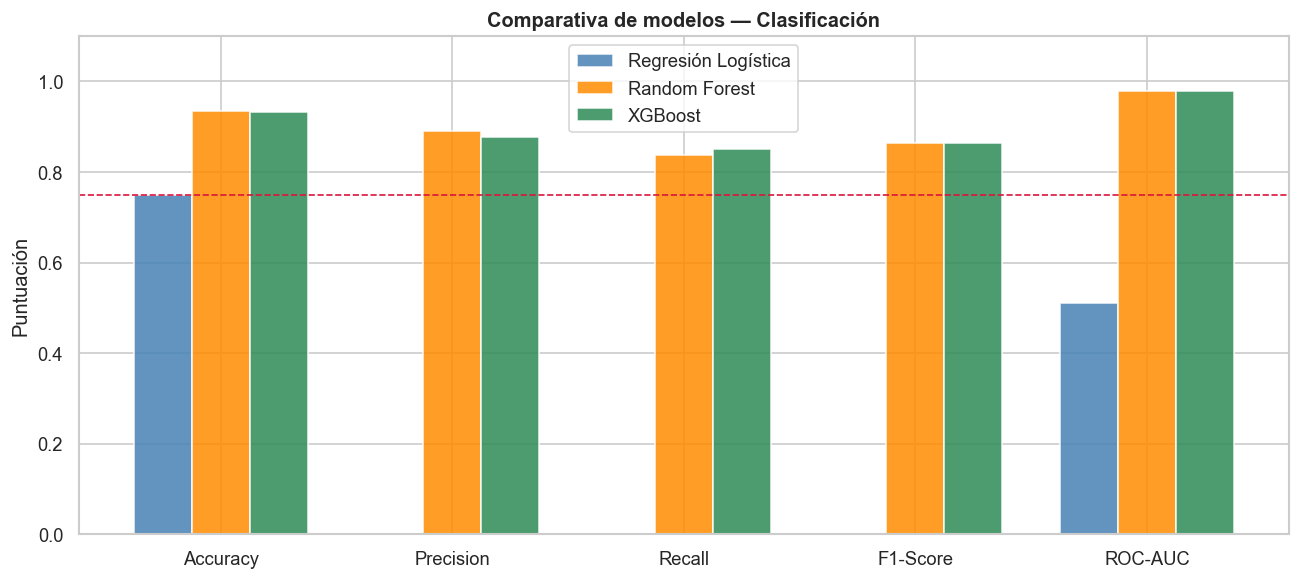

In [12]:
# Configuración de gráfico.
fig, ax = plt.subplots(figsize=(11, 5))

# Selección de métricas.
metricas = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
x = np.arange(len(metricas))
width = 0.25
colores = ['steelblue','darkorange','seagreen']

# Gráficos.
for i, (modelo, row) in enumerate(resultados_class.iterrows()):
    ax.bar(x + i * width, row[metricas], width,
           label=modelo, color=colores[i], alpha=0.85, edgecolor='white')

# Etiquetas y formato.
ax.set_xticks(x + width)
ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Puntuación')
ax.set_title('Comparativa de modelos — Clasificación', fontweight='bold')
ax.legend()
ax.axhline(0.75, color='crimson', linestyle='--', linewidth=1,
           label='Baseline (accuracy trivial)')

# Mostrar gráfico.
plt.tight_layout()
plt.savefig('./img/fig_comparativa_clasificacion.png', dpi=120, bbox_inches='tight')
plt.show()

El modelo de regresión logística tiene unos resultados bastante decepcionantes comparado con los otros dos. XGBoost y RandomForest tiene unos números bastantes similares y decentes.

Continuamos con las curvas ROC.

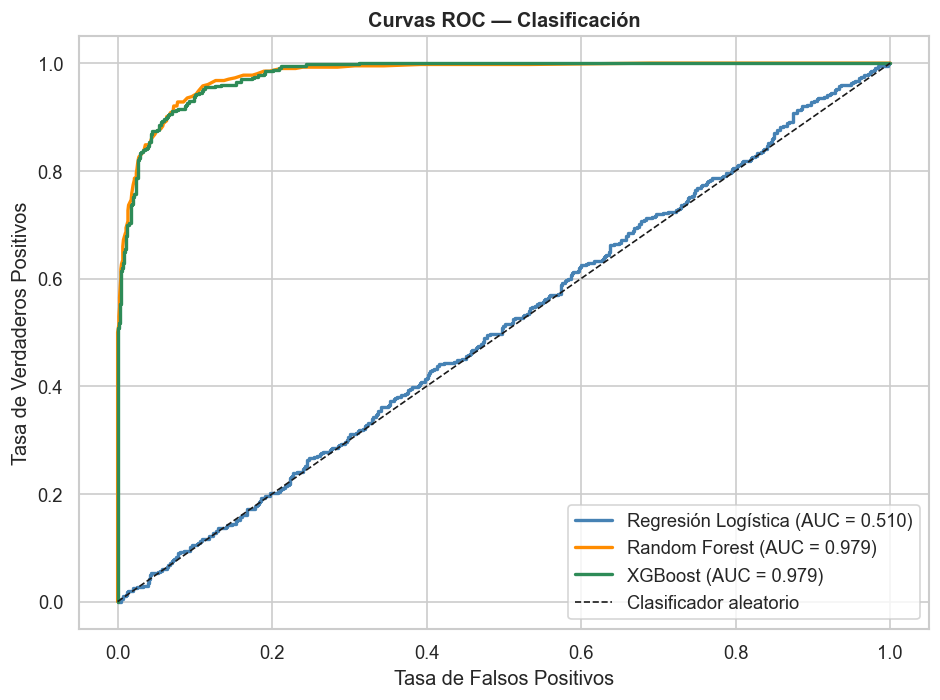

In [13]:
# Configuración del gráfico.
fig, ax = plt.subplots(figsize=(8,6))

# Selección de modelos.
modelos_roc = [
    ('Regresión Logística', lr_class, X_test_scaled, 'steelblue'),
    ('Random Forest', rf_class, X_test_class, 'darkorange'),
    ('XGBoost', xgb_class, X_test_class, 'seagreen')
]

# Dibujo de curvas ROC.
for nombre, modelo, X_test, color in modelos_roc:
    y_proba = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_class, y_proba)
    auc = roc_auc_score(y_test_class, y_proba)
    ax.plot(fpr, tpr, label=f'{nombre} (AUC = {auc:.3f})', color=color, linewidth=2)

# Etiquetas.
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curvas ROC — Clasificación', fontweight='bold')
ax.legend(loc='lower right')

# Mostrar gráfico.
plt.tight_layout()
plt.savefig('./img/fig_curvas_roc.png', dpi=120, bbox_inches='tight')
plt.show()

El modelo de regresión logística es prácticamente un clasificador aleatorio, no interesa su uso. 

Por otro lado, los modelos de Random Forest y XGBoost muestran unos resultados excelentes y muy similares. Tienen prácticamente el mismo AUC-ROC. 
RandomForest tiene un poco más de precisión, pero XGBoost tiene mayor recall (ambos diferenciados por muy poco). El recall será la métrica prioritaria, debido a que se prefiere detectar todos los casos de riesgo aunque haya algún falso positivo.

El modelo seleccionado será **XGBoost**.

El modelo seleccionado para clasificación es XGBoost.


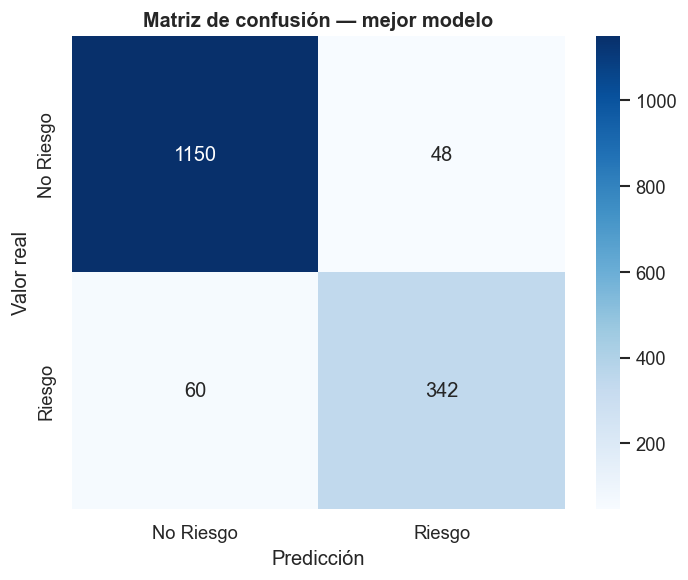

              precision    recall  f1-score   support

  Sin riesgo       0.95      0.96      0.96      1198
   En riesgo       0.88      0.85      0.86       402

    accuracy                           0.93      1600
   macro avg       0.91      0.91      0.91      1600
weighted avg       0.93      0.93      0.93      1600



In [14]:
# Selección de mejor modelo.
mejor_modelo_class = xgb_class
X_test_mejor_class = X_test_class
y_pred_mejor_class = mejor_modelo_class.predict(X_test_mejor_class)
print(f'El modelo seleccionado para clasificación es XGBoost.')

# Mostramos matriz de confusión.
cm = confusion_matrix(y_test_class, y_pred_mejor_class)

# Configuración del gráfico.
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=['No Riesgo', 'Riesgo'], yticklabels=['No Riesgo', 'Riesgo'])

# Mostramos etiquetas.
ax.set_title('Matriz de confusión — mejor modelo', fontweight='bold')
ax.set_xlabel('Predicción')
ax.set_ylabel('Valor real')

# Mostrar gráfico.
plt.tight_layout()
plt.savefig('./img/fig_matriz_confusion.png', dpi=120, bbox_inches='tight')
plt.show()

# Mostramos el reporte de clasificación.
print(classification_report(y_test_class, y_pred_mejor_class,target_names=['Sin riesgo', 'En riesgo']))

Podemos comprobar que la tasa de verdaderos (tanto como positivos como negativos) es bastante alta; 1492 casos de 1600 posibles, un 93% de precisión general.

A partir de aquí hay que poner el foco en los falsos negativos, debido a que es el error que más coste puede suponer, un alumno que no se encuentre en riesgo pero en realidad si lo esté.

De este tipo, hay 60 casos, aproximadamente un 4% de los casos. Es un buen número para un primer modelo inicial. 

Como hemos comentado en los anteriores notebooks, el modelo tiene un pequeño desbalance en la cantidad de estudiantes en riesgo y sin riesgo, se puede observar que las predicciones de las clases minoritarias tienen unos resultados algo peores.


## 03 - Regresión

El objetivo de este modelo es predecir la nota exacta de un alumno. Se utilizarán los mismos 3 modelos pero con métricas distintas.

Primero, se escalarán los datos para la regresión lineal.

In [15]:
# Standard scaler.
scaler_reg = StandardScaler()

X_train_scaled_reg = scaler_reg.fit_transform(X_train_reg) # Solo se ajusta con el train para evitar data leakage.
X_test_scaled_reg = scaler_reg.transform(X_test_reg) # Se transforma con el scaler ajustado con el train.

print(f'Escalado aplicado.')

Escalado aplicado.


Continuamos configurando y entrenando los 3 modelos.

In [16]:
# Modelo 1 - Regresión lineal.
lr_reg = LinearRegression()
lr_reg.fit(X_train_scaled_reg, y_train_reg)
print(f'Entrenamiento de regresión lineal completado.')

# Modelo 2 - Random forest.
rf_reg = RandomForestRegressor(random_state=42, n_estimators=100)
rf_reg.fit(X_train_reg, y_train_reg)
print(f'Entrenamiento de random forest completado.')

# Modelo 3 - XGBoost.
xgb_reg = XGBRegressor(random_state=42, n_estimators=100, verbosity=0)
xgb_reg.fit(X_train_scaled_reg, y_train_reg)
print(f'Entrenamiento de XGBoost completado.')

print(f'...')
print(f'Los 3 modelos han sido entrenados correctamente.')

Entrenamiento de regresión lineal completado.
Entrenamiento de random forest completado.
Entrenamiento de XGBoost completado.
...
Los 3 modelos han sido entrenados correctamente.


Una vez se han entrenado los modelos, repetimos las evaluaciones comparativas.

In [17]:
def evaluar_regresor(nombre, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    
    return {
        'Modelo' : nombre,
        'RMSE'   : rmse,
        'MAE'    : mae,
        'R²'     : r2
    }

resultados_reg = pd.DataFrame([
    evaluar_regresor('Regresión Lineal', lr_reg,  X_test_scaled_reg, y_test_reg),
    evaluar_regresor('Random Forest',     rf_reg,  X_test_reg,        y_test_reg),
    evaluar_regresor('XGBoost',           xgb_reg, X_test_reg,        y_test_reg),
])

resultados_reg.set_index('Modelo', inplace=True)
resultados_reg.round(4)

,RMSE,MAE,R²
Modelo,,,
Regresión Lineal,6.9348,5.5120,0.9021
Random Forest,6.1193,4.7246,0.9238
XGBoost,37.5955,31.3159,-1.8772


Estas métricas se interpretan de la siguiente forma:

- El RMSE es el error medio que tiene el modelo en las mismas unidades que grades. Aquí, XGBoost es claramente el que peor predice.

- El MAE es similar solo que es menos sensible a errores grandes. Es más interpretable, pero similar a RMSE, es decir, XGboost no mejora considerablemente.

- R"2 es la proporción de varianza explicada por el modelo. Cuanto más alta, significa que el modelo explica el % de la variabilidad de las notas.

Como resumen, el modelo XGBoost no funciona como regresor lineal. RandomForest tiene un MAE inferior y tiene un R2 más alto, por lo tanto será el modelo seleccionado.